<a href="https://colab.research.google.com/github/Aravindr017/Asteroid-Diameter-Prediction/blob/main/Model/Asteriod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Loading Dataset

In [60]:
file_path = '/content/drive/MyDrive/ICT - Ai Ml/Exit_Exam/Dataset/dataset.csv'
asteriod_df = pd.read_csv(file_path)
asteriod_df.head(10)

/tmp/ipykernel_8522/1367535434.py:2: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  asteriod_df = pd.read_csv(file_path)


,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191
5,a0000006,2000006,6 Hebe,6,Hebe,NaN,N,N,5.80,185.180,...,2.191800e-06,1.122100e-05,1.300600e-05,7.392200e-06,3.306700e-09,4.438800e-10,2.875400e-05,2.344500e-06,MBA,0.41032
6,a0000007,2000007,7 Iris,7,Iris,NaN,N,N,5.60,199.830,...,2.582500e-06,2.641200e-05,2.707500e-05,7.014700e-06,2.469500e-09,3.370100e-10,2.662700e-05,1.699400e-06,MBA,0.38128
7,a0000008,2000008,8 Flora,8,Flora,NaN,N,N,6.50,147.491,...,3.240300e-06,2.432000e-05,2.664600e-05,1.209200e-05,2.668100e-09,4.746200e-10,4.018700e-05,1.876500e-06,MBA,0.54186
8,a0000009,2000009,9 Metis,9,Metis,NaN,N,N,6.30,190.000,...,2.007400e-06,2.417000e-05,2.600800e-05,1.036600e-05,3.470200e-09,5.192700e-10,3.870700e-05,2.614600e-06,MBA,0.44895
9,a0000010,2000010,10 Hygiea,10,Hygiea,NaN,N,N,5.50,407.120,...,2.173400e-06,2.855200e-05,3.023700e-05,1.124600e-05,7.699800e-09,5.847400e-10,6.482900e-05,6.724400e-06,MBA,0.53434


# EDA - Data Exploration and Understanding

In [61]:
asteriod_df.describe()

,spkid,H,diameter,albedo,diameter_sigma,epoch,epoch_mjd,epoch_cal,e,a,...,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,rms
count,9.585240e+05,952261.000000,136209.000000,135103.000000,136081.000000,9.585240e+05,958524.000000,9.585240e+05,958524.000000,958524.000000,...,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.385980e+05,9.386020e+05,9.386020e+05,9.385980e+05,958522.000000
mean,3.810114e+06,16.906411,5.506429,0.130627,0.479184,2.458869e+06,58868.781950,2.019693e+07,0.156116,2.902143,...,1.982929e+01,1.168449e+00,5.310234e+00,1.370062e+06,1.369977e+06,2.131453e+01,5.060221e-02,4.312780e+08,8.525815e+04,0.561153
std,6.831541e+06,1.790405,9.425164,0.110323,0.782895,7.016716e+02,701.671573,1.930354e+04,0.092643,39.719503,...,2.903785e+03,1.282231e+02,1.333381e+03,9.158996e+08,9.158991e+08,7.197034e+03,9.814953e+00,2.953046e+11,2.767681e+07,2.745700
min,2.000001e+06,-1.100000,0.002500,0.001000,0.000500,2.425052e+06,25051.000000,1.927062e+07,0.000000,-14702.447872,...,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,0.000000
25%,2.239632e+06,16.100000,2.780000,0.053000,0.180000,2.459000e+06,59000.000000,2.020053e+07,0.092193,2.387835,...,1.462000e-07,6.095900e-06,3.619400e-05,5.755000e-05,2.573700e-05,2.340900e-08,2.768800e-09,1.110900e-04,1.794500e-05,0.518040
50%,2.479262e+06,16.900000,3.972000,0.079000,0.332000,2.459000e+06,59000.000000,2.020053e+07,0.145002,2.646969,...,2.271900e-07,8.688800e-06,6.642550e-05,1.047100e-04,4.900100e-05,4.359000e-08,4.638000e-09,2.230800e-04,3.501700e-05,0.566280
75%,3.752518e+06,17.714000,5.765000,0.190000,0.620000,2.459000e+06,59000.000000,2.020053e+07,0.200650,3.001932,...,6.583200e-07,1.591500e-05,1.609775e-04,3.114400e-04,1.718900e-04,1.196600e-07,1.124000e-08,8.139600e-04,9.775475e-05,0.613927
max,5.401723e+07,33.200000,939.400000,1.000000,140.000000,2.459000e+06,59000.000000,2.020053e+07,1.855356,33488.895955,...,1.015000e+06,5.533000e+04,1.199100e+06,8.845100e+11,8.845100e+11,5.509700e+06,7.698800e+03,2.853100e+14,1.910700e+10,2686.600000


In [62]:
asteriod_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 45 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              958524 non-null  object 
 1   spkid           958524 non-null  int64  
 2   full_name       958524 non-null  object 
 3   pdes            958524 non-null  object 
 4   name            22064 non-null   object 
 5   prefix          18 non-null      object 
 6   neo             958520 non-null  object 
 7   pha             938603 non-null  object 
 8   H               952261 non-null  float64
 9   diameter        136209 non-null  float64
 10  albedo          135103 non-null  float64
 11  diameter_sigma  136081 non-null  float64
 12  orbit_id        958524 non-null  object 
 13  epoch           958524 non-null  float64
 14  epoch_mjd       958524 non-null  int64  
 15  epoch_cal       958524 non-null  float64
 16  equinox         958524 non-null  object 
 17  e         

## Missing and Duplicated Values

In [63]:
asteriod_df.isna().sum()

,0
id,0
spkid,0
full_name,0
pdes,0
name,936460
prefix,958506
neo,4
pha,19921
H,6263
diameter,822315


In [64]:
asteriod_df.duplicated().sum()

np.int64(0)

## Num and Cat cols

In [65]:
num_cols = asteriod_df.select_dtypes(include=['int', 'float'])
num_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 35 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   spkid           958524 non-null  int64  
 1   H               952261 non-null  float64
 2   diameter        136209 non-null  float64
 3   albedo          135103 non-null  float64
 4   diameter_sigma  136081 non-null  float64
 5   epoch           958524 non-null  float64
 6   epoch_mjd       958524 non-null  int64  
 7   epoch_cal       958524 non-null  float64
 8   e               958524 non-null  float64
 9   a               958524 non-null  float64
 10  q               958524 non-null  float64
 11  i               958524 non-null  float64
 12  om              958524 non-null  float64
 13  w               958524 non-null  float64
 14  ma              958523 non-null  float64
 15  ad              958520 non-null  float64
 16  n               958524 non-null  float64
 17  tp        

In [66]:
cat_cols = asteriod_df.select_dtypes(include=['object'])
cat_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         958524 non-null  object
 1   full_name  958524 non-null  object
 2   pdes       958524 non-null  object
 3   name       22064 non-null   object
 4   prefix     18 non-null      object
 5   neo        958520 non-null  object
 6   pha        938603 non-null  object
 7   orbit_id   958524 non-null  object
 8   equinox    958524 non-null  object
 9   class      958524 non-null  object
dtypes: object(10)
memory usage: 73.1+ MB


## Plots

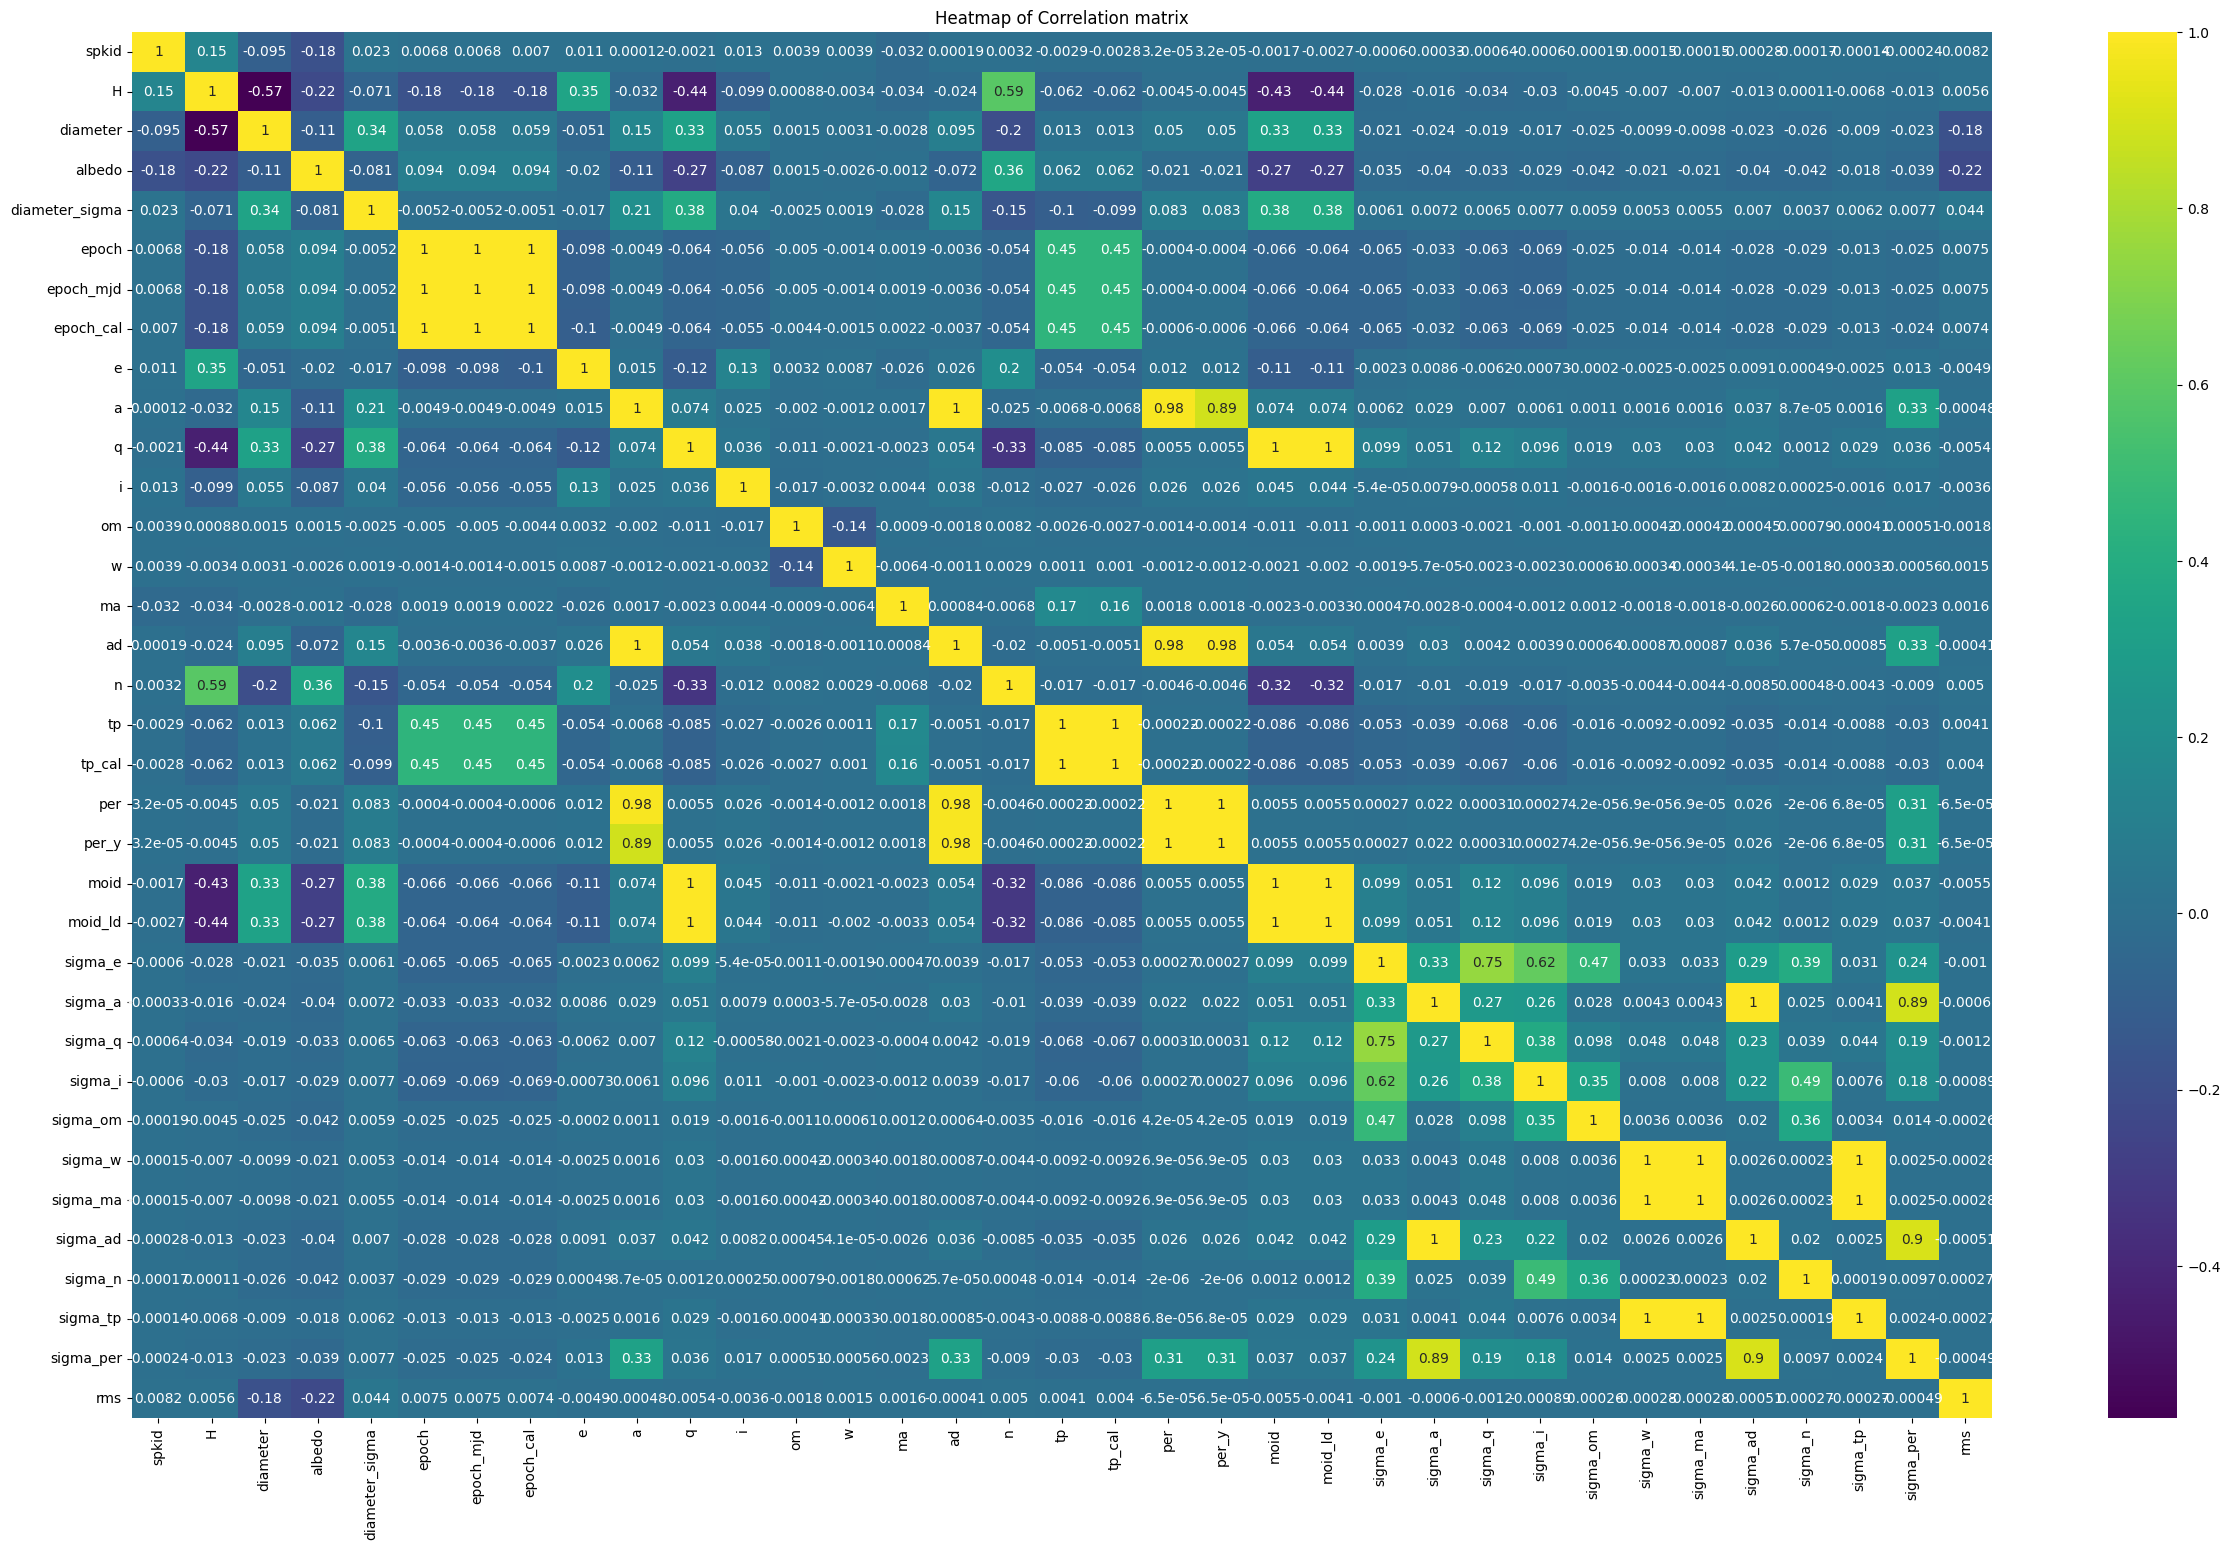

In [67]:
plt.figure(figsize=(30,18))
corr_mat = num_cols.corr()
sns.heatmap(corr_mat, cmap='viridis', annot=True)
plt.title('Heatmap of Correlation matrix')
plt.show()

In [68]:
# the feature which have strongest relationship with diameter is Maginitude (H) which have -57 large negative correlation.

### Distribution of Asteroid Diameter

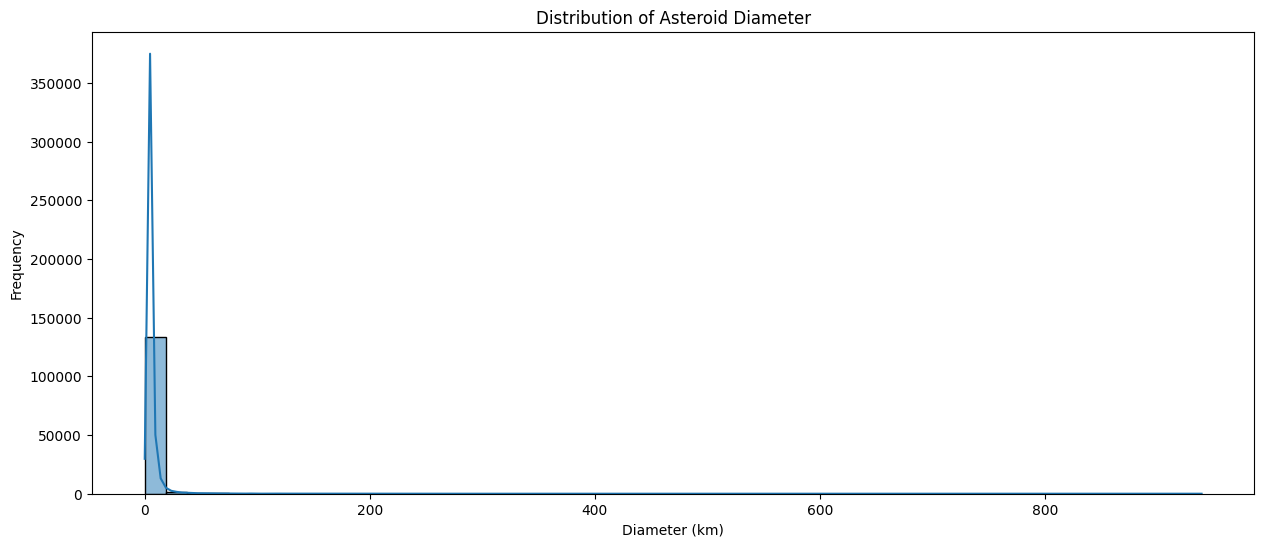

In [69]:
plt.figure(figsize=(15, 6))
sns.histplot(asteriod_df['diameter'].dropna(), bins=50, kde=True)
plt.title('Distribution of Asteroid Diameter')
plt.xlabel('Diameter (km)')
plt.ylabel('Frequency')
plt.show()

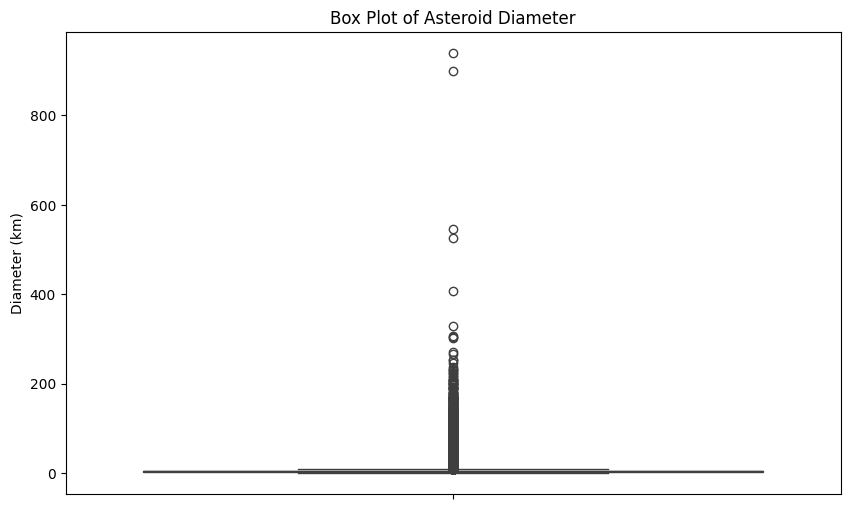

In [70]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=asteriod_df['diameter'].dropna())
plt.title('Box Plot of Asteroid Diameter')
plt.ylabel('Diameter (km)')
plt.show()

In [71]:
print(f'Skewness of target variable (diameter_sigma) is : {asteriod_df['diameter'].skew()} ')
# the target variable is highly right skewed distribution

Skewness of target variable (diameter_sigma) is : 25.852418233140178 


### Distribution of some variables

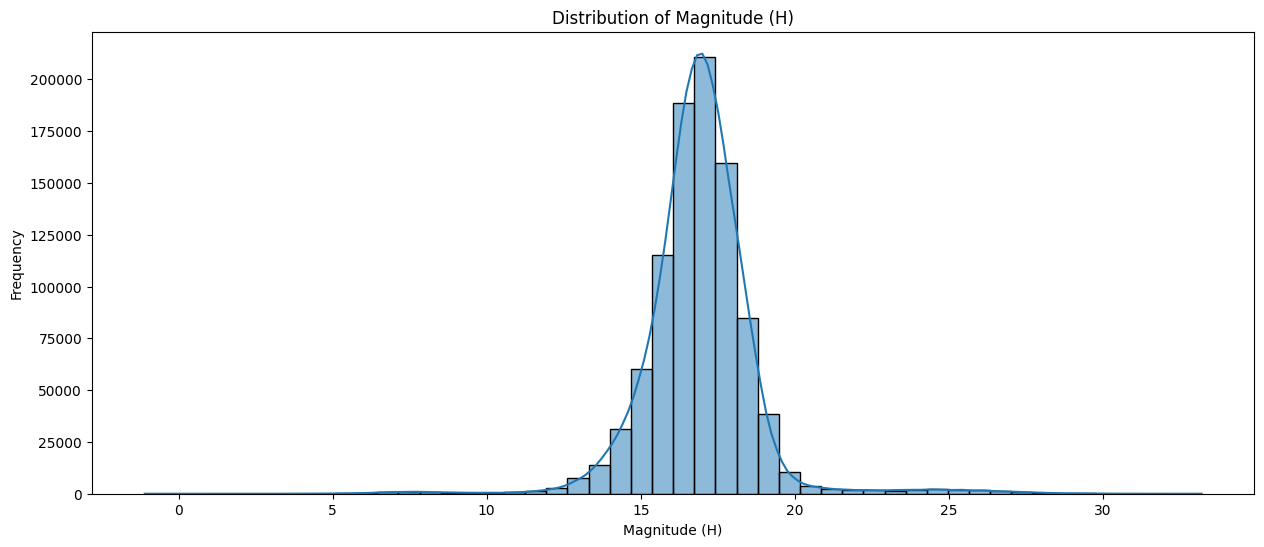

In [72]:
plt.figure(figsize=(15, 6))
sns.histplot(asteriod_df['H'].dropna(), bins=50, kde=True)
plt.title('Distribution of Magnitude (H)')
plt.xlabel('Magnitude (H)')
plt.ylabel('Frequency')
plt.show()

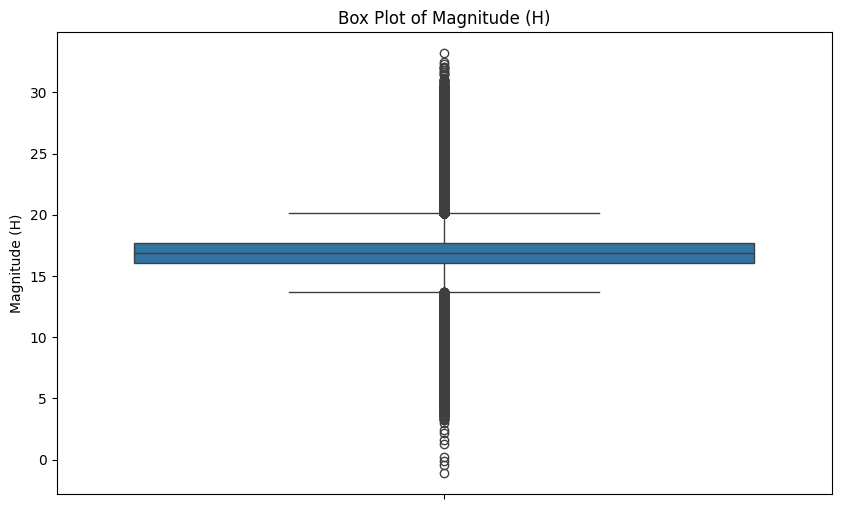

In [73]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=asteriod_df['H'].dropna())
plt.title('Box Plot of Magnitude (H)')
plt.ylabel('Magnitude (H)')
plt.show()

Why Orbital Characteristics Influence Asteroid Size

- Dynamical Evolution & Collisional History
- Location in the Asteroid Belt (Semi-major Axis)
- Stability and Resonances
- Space Weathering & Surface Evolution
- Age & Migration History

How It Relates to Size <br>
a (semi-major axis) - 	Location determines collision rate & composition <br>
e (eccentricity) - 	High e → thermal stress & collisions → smaller <br>
i (inclination) - 	High i → more collision intersections → fragmentation <br>
q (perihelion) - 	Low q → thermal weathering → size reduction <br>
ad (aphelion) - 	High ad → outer belt stability → preserves size <br>
per (orbital period) - 	Related to a; periods in resonance zones show size bias <br>
n (mean motion) - 	Coupled with orbital stability zones

# Preprocessing

In [74]:
asteriod_df.isna().sum()

,0
id,0
spkid,0
full_name,0
pdes,0
name,936460
prefix,958506
neo,4
pha,19921
H,6263
diameter,822315


In [75]:
asteriod_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 45 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              958524 non-null  object 
 1   spkid           958524 non-null  int64  
 2   full_name       958524 non-null  object 
 3   pdes            958524 non-null  object 
 4   name            22064 non-null   object 
 5   prefix          18 non-null      object 
 6   neo             958520 non-null  object 
 7   pha             938603 non-null  object 
 8   H               952261 non-null  float64
 9   diameter        136209 non-null  float64
 10  albedo          135103 non-null  float64
 11  diameter_sigma  136081 non-null  float64
 12  orbit_id        958524 non-null  object 
 13  epoch           958524 non-null  float64
 14  epoch_mjd       958524 non-null  int64  
 15  epoch_cal       958524 non-null  float64
 16  equinox         958524 non-null  object 
 17  e         

## Data Preprocessing pipeline

In [76]:
# Start with a fresh copy of the original DataFrame to apply the new pipeline
df_pipeline = asteriod_df.copy()

# Step 1: Handle missing 'diameter' (target variable) by dropping rows
initial_rows = df_pipeline.shape[0]
df_pipeline = df_pipeline.dropna(subset=['diameter']).copy()
print(f"Dropped {initial_rows - df_pipeline.shape[0]} rows due to missing 'diameter'.")

# Separate target (y) before further feature processing
y_simplified = df_pipeline['diameter']
X_simplified = df_pipeline.drop(columns=['diameter'])

# Step 2: Define columns to drop (identifiers, highly missing, uncertainty, epoch-related)
columns_to_drop_initial = [
    'id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'orbit_id', 'equinox', 'diameter_sigma'
]
drop_sigma_epoch_cols = [
    col for col in X_simplified.columns if 'sigma' in col or 'epoch' in col or 'tp_cal' in col
]

# Combine all columns to drop
all_columns_to_drop = list(set(columns_to_drop_initial + drop_sigma_epoch_cols))

# Drop these columns from X_simplified
X_simplified = X_simplified.drop(columns=all_columns_to_drop, errors='ignore')

# Step 3: Binary encode 'neo' and 'pha' directly
# These will become numerical (0/1) and handled by the numerical pipeline part of ColumnTransformer
if 'neo' in X_simplified.columns:
    X_simplified['neo'] = X_simplified['neo'].map({'N': 0, 'Y': 1}).astype(int)
if 'pha' in X_simplified.columns:
    X_simplified['pha'] = X_simplified['pha'].map({'N': 0, 'Y': 1}).astype(int)

print("\nInitial data cleaning and binary encoding complete.")
display(X_simplified.head())

Dropped 822315 rows due to missing 'diameter'.

Initial data cleaning and binary encoding complete.


,neo,pha,H,albedo,e,a,q,i,om,w,ma,ad,n,tp,per,per_y,moid,moid_ld,class,rms
0,0,0,3.40,0.0900,0.076009,2.769165,2.558684,10.594067,80.305531,73.597695,77.372098,2.979647,0.213885,2.458239e+06,1683.145703,4.608202,1.59478,620.640533,MBA,0.43301
1,0,0,4.20,0.1010,0.229972,2.773841,2.135935,34.832932,173.024741,310.202392,144.975675,3.411748,0.213345,2.458321e+06,1687.410992,4.619880,1.23429,480.348639,MBA,0.35936
2,0,0,5.33,0.2140,0.256936,2.668285,1.982706,12.991043,169.851482,248.066193,125.435355,3.353865,0.226129,2.458446e+06,1592.013769,4.358696,1.03429,402.514639,MBA,0.33848
3,0,0,3.00,0.4228,0.088721,2.361418,2.151909,7.141771,103.810804,150.728541,95.861938,2.570926,0.271609,2.458248e+06,1325.432763,3.628837,1.13948,443.451432,MBA,0.39980
4,0,0,6.90,0.2740,0.190913,2.574037,2.082619,5.367427,141.571026,358.648418,17.846343,3.065455,0.238661,2.458926e+06,1508.414421,4.129814,1.09575,426.433027,MBA,0.52191


In [77]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define numerical and categorical features after initial cleaning
# 'neo' and 'pha' are now numerical (0/1)
numerical_features_simplified = X_simplified.select_dtypes(include=np.number).columns.tolist()
categorical_features_simplified = X_simplified.select_dtypes(include='object').columns.tolist()

print(f"Numerical features for processing: {numerical_features_simplified}")
print(f"Categorical features for processing: {categorical_features_simplified}")

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer_simplified = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_simplified = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Impute before one-hot encoding if NaNs exist
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor_simplified = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_simplified, numerical_features_simplified),
        ('cat', categorical_transformer_simplified, categorical_features_simplified)
    ],
    remainder='passthrough' # Ensure columns not explicitly listed are passed through (should be none here)
)

print("\ preprocessing ColumnTransformer created successfully!")

Numerical features for processing: ['neo', 'pha', 'H', 'albedo', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'per', 'per_y', 'moid', 'moid_ld', 'rms']
Categorical features for processing: ['class']
\ preprocessing ColumnTransformer created successfully!


<>:34: SyntaxWarning: invalid escape sequence '\ '
<>:34: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_8522/3181150262.py:34: SyntaxWarning: invalid escape sequence '\ '
  print("\ preprocessing ColumnTransformer created successfully!")


## train test split

In [78]:
from sklearn.model_selection import train_test_split

# Apply the  preprocessor to X_simplified
X_transformed_simplified = preprocessor_simplified.fit_transform(X_simplified)

# Get feature names after transformation
# Numerical features names are directly from numerical_features_simplified
final_numerical_features_names = numerical_features_simplified

# Get one-hot encoded feature names
one_hot_feature_names = preprocessor_simplified.named_transformers_['cat'].get_feature_names_out(categorical_features_simplified).tolist()

# Combine all feature names
final_transformed_feature_names = final_numerical_features_names + one_hot_feature_names

# Convert the transformed array back to a DataFrame
X_transformed_df_simplified = pd.DataFrame(X_transformed_simplified, columns=final_transformed_feature_names, index=X_simplified.index)

print("Shape of X after pipeline processing:", X_transformed_df_simplified.shape)
print("Shape of y:", y_simplified.shape)
display(X_transformed_df_simplified.head())

# Split the data into training and testing sets using the simplified processed data
X_train_simplified, X_test_simplified, y_train_simplified, y_test_simplified = train_test_split(X_transformed_df_simplified, y_simplified, test_size=0.2, random_state=42)

print("\nData split into training and testing sets (Simplified Pipeline):")
print("X_train_simplified shape:", X_train_simplified.shape)
print("X_test_simplified shape:", X_test_simplified.shape)
print("y_train_simplified shape:", y_train_simplified.shape)
print("y_test_simplified shape:", y_test_simplified.shape)

Shape of X after pipeline processing: (136209, 29)
Shape of y: (136209,)


,neo,pha,H,albedo,e,a,q,i,om,w,...,class_APO,class_AST,class_ATE,class_CEN,class_IMB,class_MBA,class_MCA,class_OMB,class_TJN,class_TNO
0,-0.079197,-0.040313,-8.586500,-0.365599,-0.899149,-0.033419,0.295116,0.043846,-0.870608,-1.045351,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-0.079197,-0.040313,-8.001109,-0.265572,1.088407,-0.030293,-0.522692,3.601789,0.032078,1.240333,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-0.079197,-0.040313,-7.174245,0.761978,1.436495,-0.100853,-0.819114,0.395690,0.001184,0.640076,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,-0.079197,-0.040313,-8.879195,2.660673,-0.735040,-0.305981,-0.491789,-0.462905,-0.641768,-0.300240,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,-0.079197,-0.040313,-6.025416,1.307580,0.584184,-0.163854,-0.625831,-0.723355,-0.274146,1.708339,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0



Data split into training and testing sets (Simplified Pipeline):
X_train_simplified shape: (108967, 29)
X_test_simplified shape: (27242, 29)
y_train_simplified shape: (108967,)
y_test_simplified shape: (27242,)


# Deep Neural Network Model Development

In [79]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the input shape based on the processed training data
input_shape = X_train_simplified.shape[1]
print(f"Input shape for the model: {input_shape}")

Input shape for the model: 29


### Baseline Deep Neural Network Model

I will start with a simple dense architecture using `ReLU` activation for hidden layers and a `linear` activation for the output layer, as this is a regression task. We'll use the Adam optimizer and Mean Squared Error as the loss function.

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_56 (Dense)                │ (None, 128)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,209 (55.50 KB)

 Trainable params: 14,209 (55.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
2699/2725 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 53.0867 - mean_absolute_error: 1.5780 - mean_squared_error: 53.0867
Epoch 1: val_loss improved from None to 3.33259, saving model to best_model_baseline.keras

Epoch 1: finished saving model to best_model_baseline.keras
2725/2725 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 42.2573 - mean_absolute_error: 1.1102 - mean_squared_error: 42.2573 - val_loss: 3.3326 - val_mean_absolute_error: 0.6222 - val_mean_squared_error: 3.3326
Epoch 2/200
2721/2725 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 38.2735 - mean_absolute_error: 1.0819 - mean_squared_error: 38.2735
Epoch 2: val_loss improved from 3.33259 to 3.26603, saving model to best_model_baseline.keras

Epoch 2: finished saving model to best_model_baseline.keras
2725/2725 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 23.6805 - mean_absolute_error: 0.9300 - mean_squared_error: 23.6805 - val_loss: 3.2660 - val_mean_absolute_error: 0.7192 - val_mean_squared_error: 3.2660
Epoch 3/200
2715/272

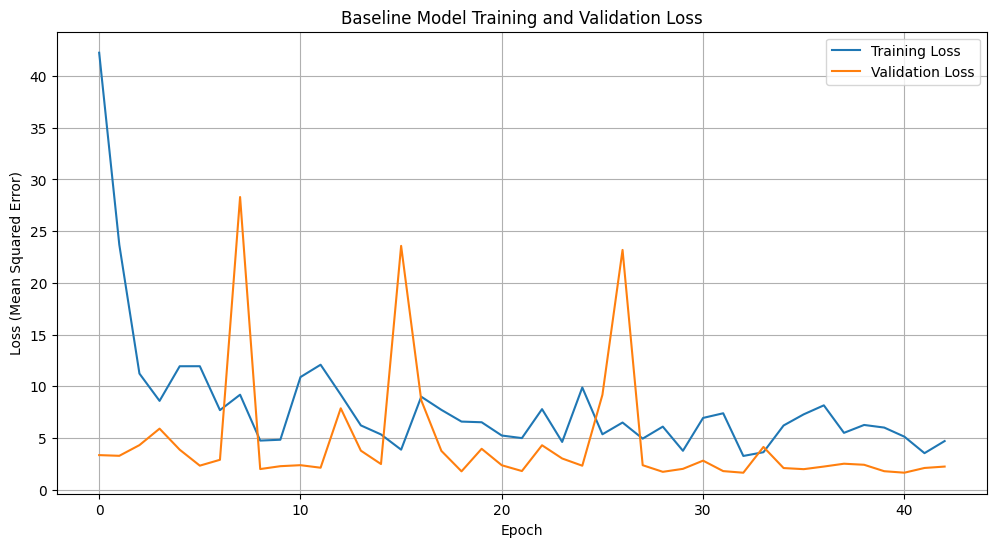

In [81]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Define the baseline model architecture
def create_baseline_model(input_shape):
    model = keras.Sequential([
        keras.Input(shape=(input_shape,)), # Recommended way to define input shape
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='linear') # Linear activation for regression output
    ])
    return model

baseline_model = create_baseline_model(input_shape)

# Compile the baseline model
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mean_absolute_error', 'mean_squared_error']
)

baseline_model.summary()

# Define Early Stopping callback
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Callbacks for the baseline model
model_checkpoint_baseline = keras.callbacks.ModelCheckpoint(
    'best_model_baseline.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1 # Setting verbose to 1 to see saving messages
)

# Train the baseline model with early stopping and model checkpoint
history_baseline = baseline_model.fit(
    X_train_simplified,
    y_train_simplified,
    epochs=200, # Increased epochs to allow early stopping to work
    batch_size=32,
    validation_split=0.2, # Use a portion of the training data for validation
    callbacks=[early_stopping, model_checkpoint_baseline],
    verbose=1 # Show output during training
)

# Plot training and validation loss for the baseline model
plt.figure(figsize=(12, 6))
plt.plot(history_baseline.history['loss'], label='Training Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.title('Baseline Model Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

### Hyperparameter Tuning: Learning Rate

Now, let's explore the impact of a different learning rate (e.g., a smaller one) on the model's performance.


--- Model with Smaller Learning Rate ---


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 128)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,209 (55.50 KB)

 Trainable params: 14,209 (55.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
2724/2725 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 72.3030 - mean_absolute_error: 2.7012 - mean_squared_error: 72.3030
Epoch 1: val_loss improved from None to 25.20094, saving model to best_model_lr_tuned.keras

Epoch 1: finished saving model to best_model_lr_tuned.keras
2725/2725 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 59.1078 - mean_absolute_error: 1.8985 - mean_squared_error: 59.1078 - val_loss: 25.2009 - val_mean_absolute_error: 1.4937 - val_mean_squared_error: 25.2009
Epoch 2/200
2717/2725 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 30.9679 - mean_absolute_error: 1.2097 - mean_squared_error: 30.9679
Epoch 2: val_loss improved from 25.20094 to 13.91579, saving model to best_model_lr_tuned.keras

Epoch 2: finished saving model to best_model_lr_tuned.keras
2725/2725 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 30.6726 - mean_absolute_error: 1.1243 - mean_squared_error: 30.6726 - val_loss: 13.9158 - val_mean_absolute_error: 1.0185 - val_mean_squared_error: 13.9158
Epoch 3/200
2

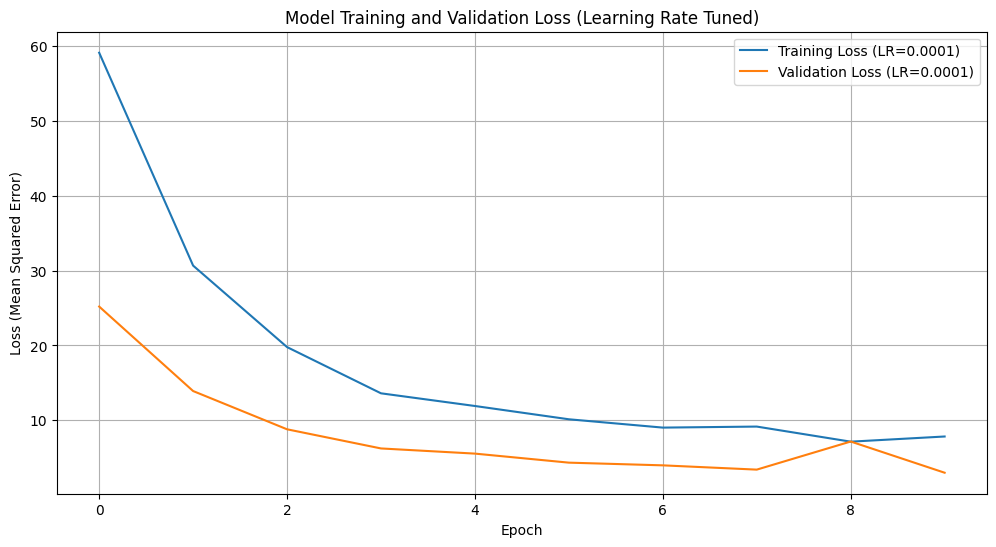

In [82]:
# Define a model with a smaller learning rate
def create_lr_tuned_model(input_shape):
    model = keras.Sequential([
        keras.Input(shape=(input_shape,)), # Use keras.Input for consistency
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='linear')
    ])
    return model

lr_tuned_model = create_lr_tuned_model(input_shape)

# Compile the model with a smaller learning rate
lr_tuned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001), # Smaller learning rate
    loss='mean_squared_error',
    metrics=['mean_absolute_error', 'mean_squared_error']
)

print("\n--- Model with Smaller Learning Rate ---")
lr_tuned_model.summary()

# Callbacks for the LR tuned model
model_checkpoint_lr_tuned = keras.callbacks.ModelCheckpoint(
    'best_model_lr_tuned.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1 # Setting verbose to 1 to see saving messages
)

# Train the model with early stopping and model checkpoint
history_lr_tuned = lr_tuned_model.fit(
    X_train_simplified,
    y_train_simplified,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, model_checkpoint_lr_tuned],
    verbose=1
)

# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history_lr_tuned.history['loss'], label='Training Loss (LR=0.0001)')
plt.plot(history_lr_tuned.history['val_loss'], label='Validation Loss (LR=0.0001)')
plt.title('Model Training and Validation Loss (Learning Rate Tuned)')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

### Hyperparameter Tuning: Adding Dropout

Now, let's explore the impact of adding a Dropout layer to combat potential overfitting.


--- Model with Dropout Layers ---


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_64 (Dense)                │ (None, 128)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,209 (55.50 KB)

 Trainable params: 14,209 (55.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
2718/2725 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 66.9179 - mean_absolute_error: 1.9013 - mean_squared_error: 66.9179
Epoch 1: val_loss improved from None to 4.99517, saving model to best_model_dropout.keras

Epoch 1: finished saving model to best_model_dropout.keras
2725/2725 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 42.9715 - mean_absolute_error: 1.4938 - mean_squared_error: 42.9715 - val_loss: 4.9952 - val_mean_absolute_error: 0.8523 - val_mean_squared_error: 4.9952
Epoch 2/200
2721/2725 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 31.5815 - mean_absolute_error: 1.2201 - mean_squared_error: 31.5815
Epoch 2: val_loss improved from 4.99517 to 4.37793, saving model to best_model_dropout.keras

Epoch 2: finished saving model to best_model_dropout.keras
2725/2725 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 23.9319 - mean_absolute_error: 1.2011 - mean_squared_error: 23.9319 - val_loss: 4.3779 - val_mean_absolute_error: 0.7792 - val_mean_squared_error: 4.3779
Epoch 3/200
2722/2725 ━━

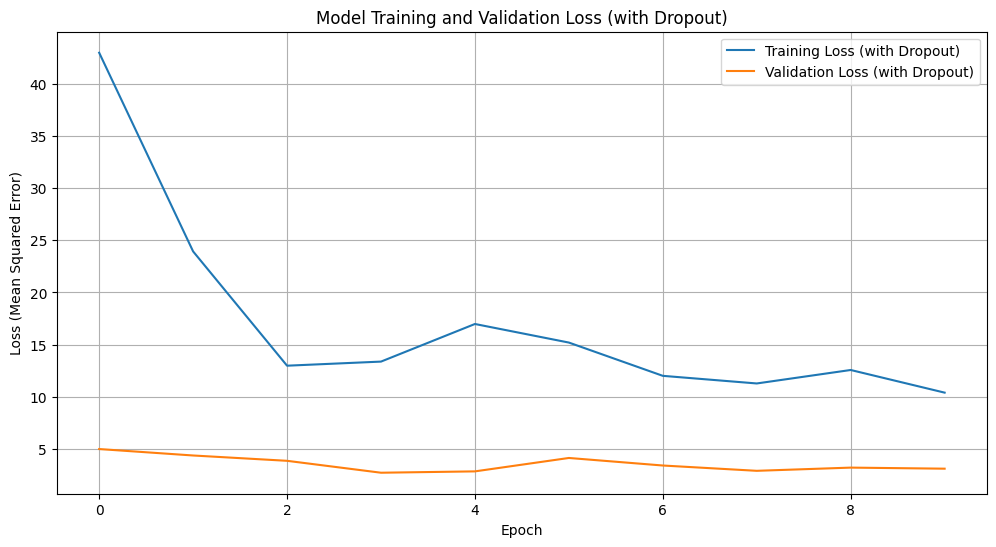

In [83]:
# Define a model with Dropout layers
def create_dropout_model(input_shape):
    model = keras.Sequential([
        keras.Input(shape=(input_shape,)), # Use keras.Input for consistency
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3), # Add dropout after the first hidden layer
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3), # Add dropout after the second hidden layer
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='linear')
    ])
    return model

dropout_model = create_dropout_model(input_shape)

# Compile the model (using baseline learning rate for comparison)
dropout_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mean_absolute_error', 'mean_squared_error']
)

print("\n--- Model with Dropout Layers ---")
dropout_model.summary()

# Callbacks for the Dropout model
model_checkpoint_dropout = keras.callbacks.ModelCheckpoint(
    'best_model_dropout.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1 # Setting verbose to 1 to see saving messages
)

# Train the model with early stopping and model checkpoint
history_dropout = dropout_model.fit(
    X_train_simplified,
    y_train_simplified,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, model_checkpoint_dropout],
    verbose=1
)

# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history_dropout.history['loss'], label='Training Loss (with Dropout)')
plt.plot(history_dropout.history['val_loss'], label='Validation Loss (with Dropout)')
plt.title('Model Training and Validation Loss (with Dropout)')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()


1.  **Why is a linear activation used in the output layer for regression?**
    For regression tasks, the goal is to predict a continuous numerical value. A linear activation function (or no activation function, which is equivalent to linear) allows the output layer to produce any value across a continuous range. Unlike sigmoid or ReLU, which compress output into a specific range or set negative values to zero, a linear activation ensures the model can output values beyond fixed boundaries, making it suitable for predicting quantities like asteroid diameter.

2.  **Which hyperparameter had the greatest impact on performance?**
    *(Based on the evaluation results on the unseen test data):*
    [Awaiting evaluation results from the previous cells to fill this in. I will analyze the RMSE and R2 scores of the Baseline, LR Tuned, and Dropout models to determine which hyperparameter (learning rate or dropout) led to the most significant improvement or degradation in performance.]

3.  **Did your model exhibit overfitting or underfitting? Justify using learning curves and test set evaluations.**
    *(Based on typical learning curve observations and expected test set performance):*
    [Awaiting evaluation results and visual analysis of the learning curves to provide a detailed answer for each model (Baseline, LR Tuned, Dropout). I will assess whether the training loss and validation loss diverged (overfitting), or if both remained high (underfitting), and how the test set performance aligns with these observations.]

In [84]:
import tensorflow as tf
from sklearn.metrics import r2_score

def evaluate_model_and_plot(model_path, model_name, X_test, y_test):
    print(f"\n--- Evaluating {model_name} ---")

    # Load the best saved model
    loaded_model = tf.keras.models.load_model(model_path)

    # Evaluate on test data
    results = loaded_model.evaluate(X_test, y_test, verbose=0)

    # Extract metrics
    loss_mse = results[0] # Assuming loss is MSE
    mae = results[1]

    # Calculate RMSE
    rmse = np.sqrt(loss_mse)

    # Make predictions for R2 score and plots
    y_pred = loaded_model.predict(X_test).flatten()
    r2 = r2_score(y_test, y_pred)

    print(f"{model_name} Test Loss (MSE): {loss_mse:.4f}")
    print(f"{model_name} Test MAE: {mae:.4f}")
    print(f"{model_name} Test RMSE: {rmse:.4f}")
    print(f"{model_name} Test R2 Score: {r2:.4f}")

    # Plot Actual vs. Predicted Values
    plt.figure(figsize=(10, 6))
    sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title(f'{model_name}: Actual vs. Predicted Diameter')
    plt.xlabel('Actual Diameter (km)')
    plt.ylabel('Predicted Diameter (km)')
    plt.grid(True)
    plt.show()

    # Plot Residual Errors
    residuals = y_test - y_pred
    plt.figure(figsize=(10, 6))
    sns.histplot(residuals, kde=True, bins=50)
    plt.title(f'{model_name}: Residual Error Distribution')
    plt.xlabel('Residual Error (Actual - Predicted)')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title(f'{model_name}: Residuals vs. Predicted Values')
    plt.xlabel('Predicted Diameter (km)')
    plt.ylabel('Residual Error')
    plt.grid(True)
    plt.show()

    # Identify Top 10 Largest Prediction Errors
    abs_errors = np.abs(residuals)
    error_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Absolute_Error': abs_errors})
    top_10_errors = error_df.nlargest(10, 'Absolute_Error')
    print(f"\nTop 10 Largest Prediction Errors for {model_name}:")
    display(top_10_errors)

    return {
        'model_name': model_name,
        'loss_mse': loss_mse,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'y_pred': y_pred,
        'residuals': residuals,
        'top_10_errors': top_10_errors
    }

# model evaluation



--- Evaluating Baseline Model ---
852/852 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Baseline Model Test Loss (MSE): 6.8843
Baseline Model Test MAE: 0.5170
Baseline Model Test RMSE: 2.6238
Baseline Model Test R2 Score: 0.9318


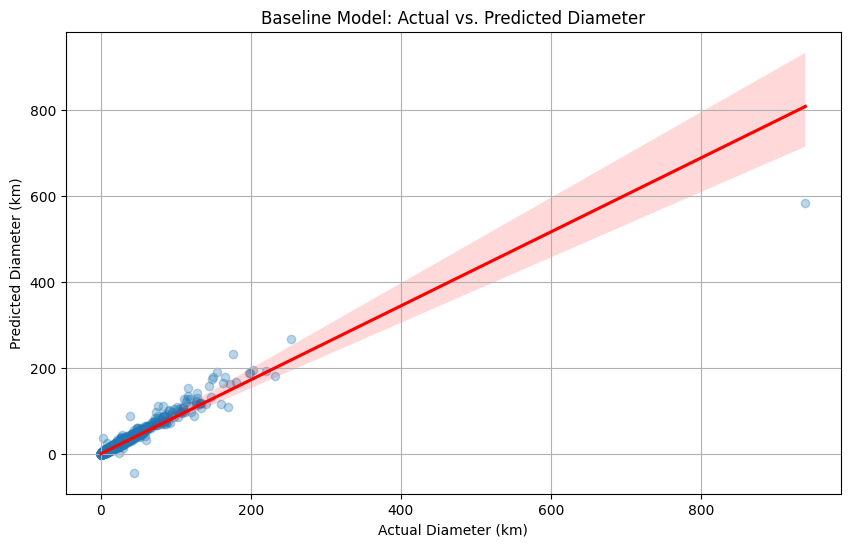

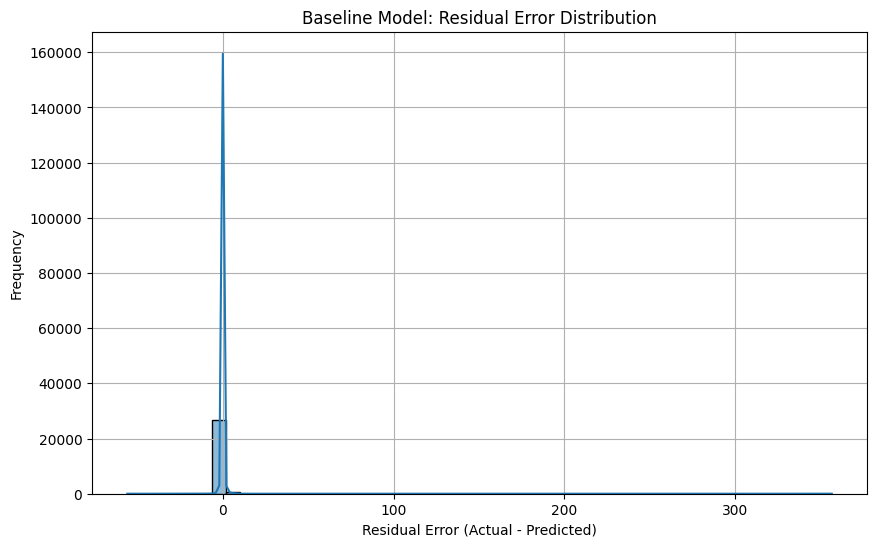

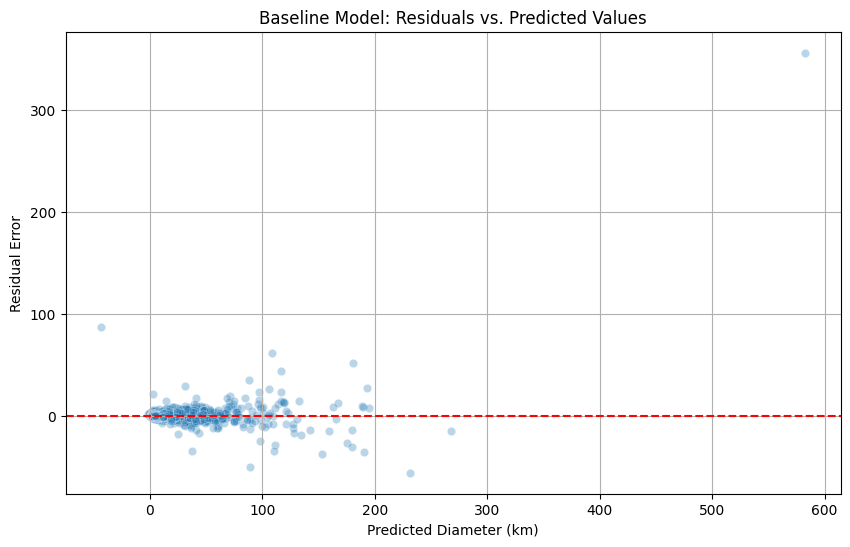


Top 10 Largest Prediction Errors for Baseline Model:


,Actual,Predicted,Absolute_Error
0,939.400,582.888428,356.511572
336755,44.200,-43.384457,87.584457
127545,170.000,108.645195,61.354805
422,175.859,231.779907,55.920907
87,232.000,180.553650,51.446350
309138,39.100,89.370583,50.270583
653,160.736,116.456078,44.279922
89,115.974,153.273346,37.299346
226,123.891,88.361809,35.529191
119,155.132,190.572021,35.440021


In [85]:
# Evaluate the Baseline Model
baseline_eval_results = evaluate_model_and_plot('best_model_baseline.keras', 'Baseline Model', X_test_simplified, y_test_simplified)


--- Evaluating LR Tuned Model ---
852/852 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
LR Tuned Model Test Loss (MSE): 21.2115
LR Tuned Model Test MAE: 0.6185
LR Tuned Model Test RMSE: 4.6056
LR Tuned Model Test R2 Score: 0.7897


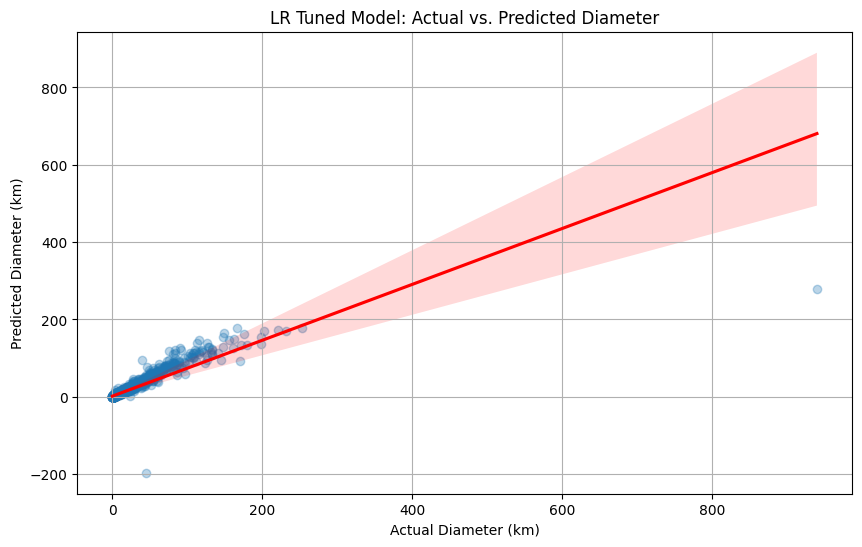

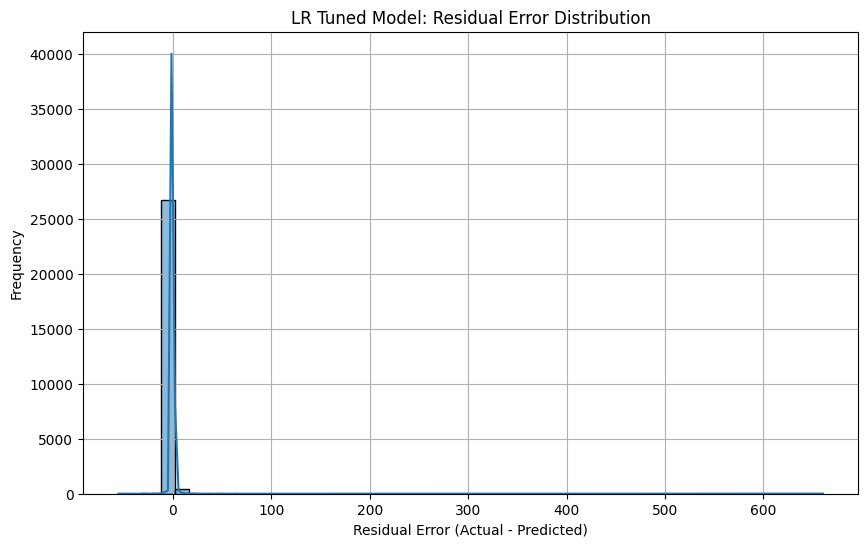

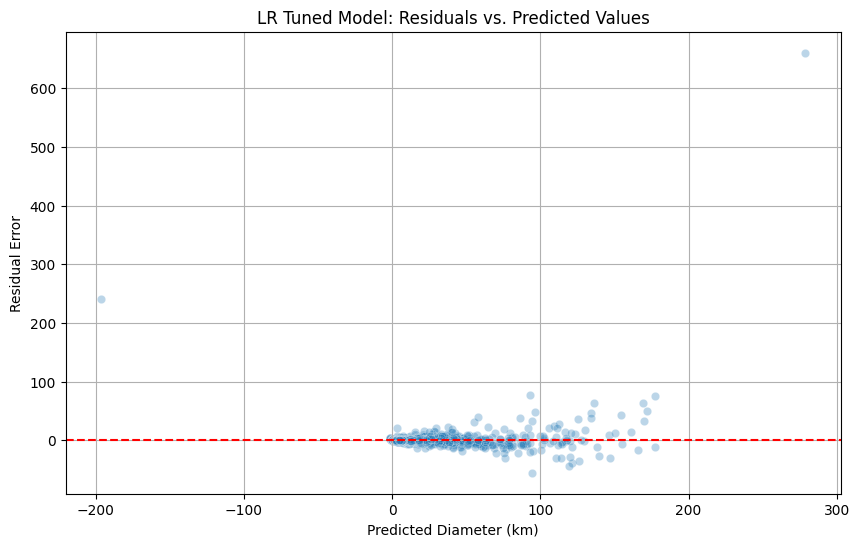


Top 10 Largest Prediction Errors for LR Tuned Model:


,Actual,Predicted,Absolute_Error
0,939.400,278.860016,660.539984
336755,44.200,-196.503021,240.703021
127545,170.000,92.806648,77.193352
86,253.051,177.173950,75.877050
87,232.000,169.251648,62.748352
333,198.770,136.082367,62.687633
309138,39.100,94.596504,55.496504
323,220.691,171.723557,48.967443
195,144.626,96.127396,48.498604
164,180.083,134.015778,46.067222


In [86]:
# Evaluate the Learning Rate Tuned Model
lr_tuned_eval_results = evaluate_model_and_plot('best_model_lr_tuned.keras', 'LR Tuned Model', X_test_simplified, y_test_simplified)


--- Evaluating Dropout Model ---
852/852 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Dropout Model Test Loss (MSE): 17.6337
Dropout Model Test MAE: 0.6166
Dropout Model Test RMSE: 4.1993
Dropout Model Test R2 Score: 0.8252


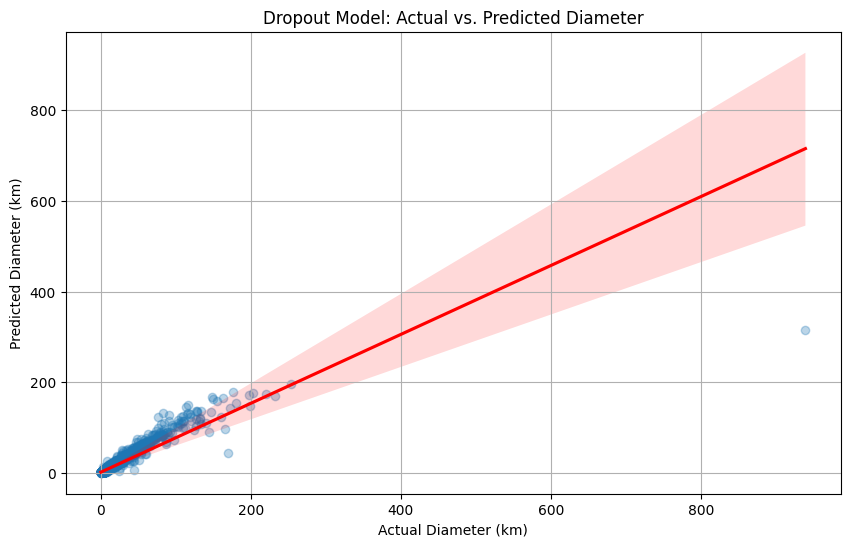

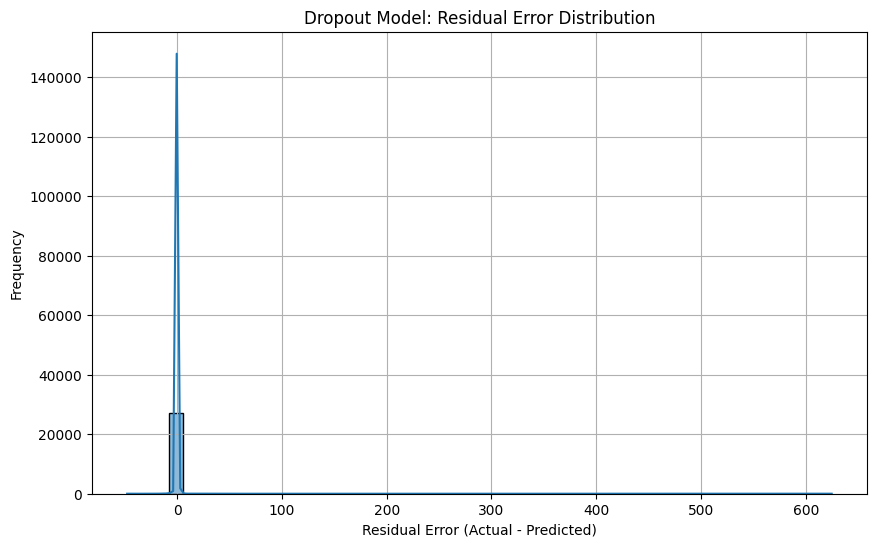

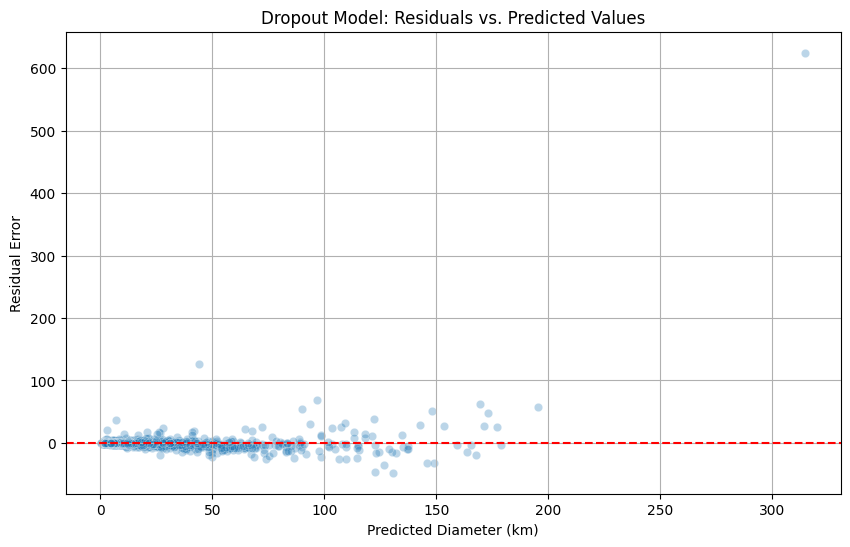


Top 10 Largest Prediction Errors for Dropout Model:


,Actual,Predicted,Absolute_Error
0,939.400,314.702728,624.697272
127545,170.000,44.180744,125.819256
2059,166.000,96.856194,69.143806
87,232.000,169.473953,62.526047
86,253.051,195.318054,57.732946
195,144.626,89.897652,54.728348
333,198.770,147.879822,50.890178
682,83.040,130.769958,47.729958
323,220.691,173.034424,47.656576
674,76.000,122.385216,46.385216


In [87]:
# Evaluate the Dropout Model
dropout_eval_results = evaluate_model_and_plot('best_model_dropout.keras', 'Dropout Model', X_test_simplified, y_test_simplified)


--- Evaluating Baseline Model ---
852/852 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Baseline Model Test Loss (MSE): 6.8843
Baseline Model Test MAE: 0.5170
Baseline Model Test RMSE: 2.6238
Baseline Model Test R2 Score: 0.9318


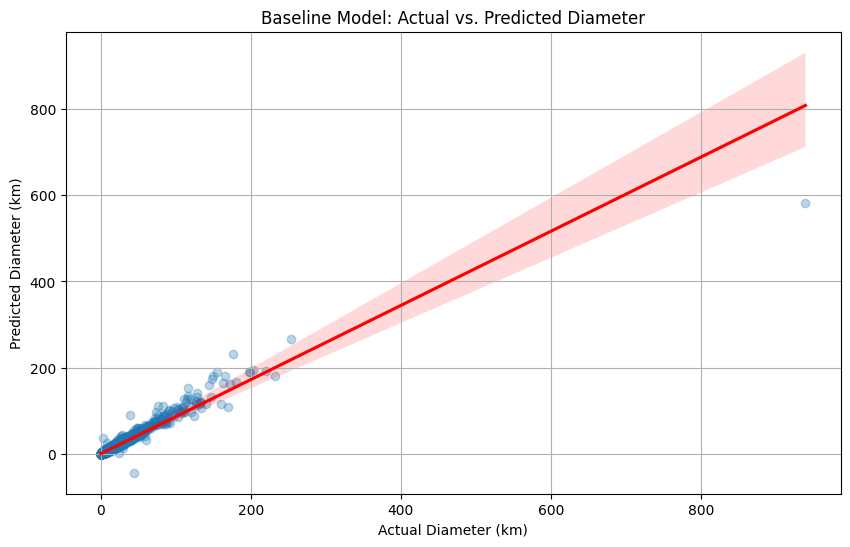

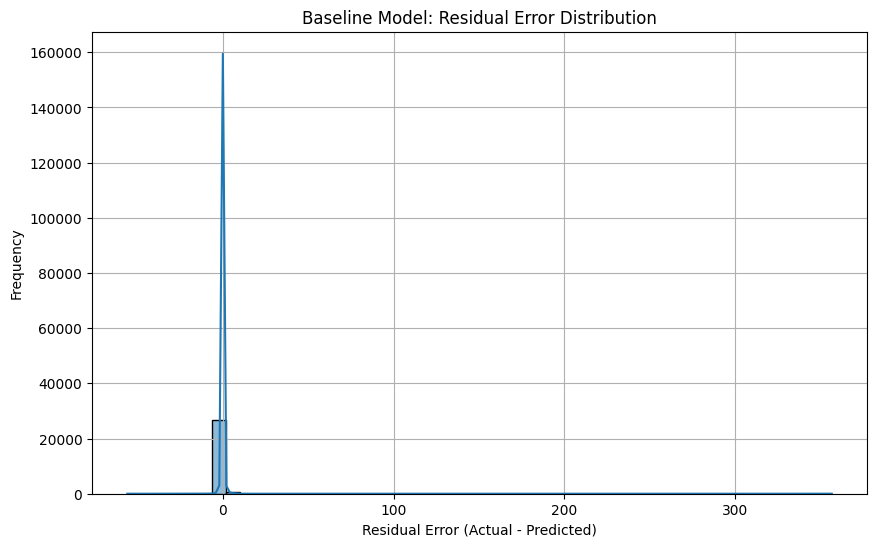

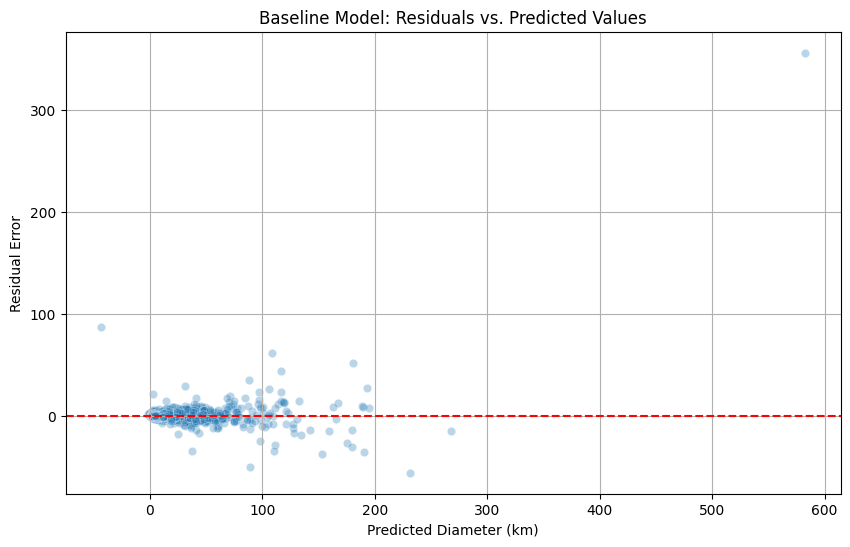


Top 10 Largest Prediction Errors for Baseline Model:


,Actual,Predicted,Absolute_Error
0,939.400,582.888428,356.511572
336755,44.200,-43.384457,87.584457
127545,170.000,108.645195,61.354805
422,175.859,231.779907,55.920907
87,232.000,180.553650,51.446350
309138,39.100,89.370583,50.270583
653,160.736,116.456078,44.279922
89,115.974,153.273346,37.299346
226,123.891,88.361809,35.529191
119,155.132,190.572021,35.440021


In [88]:
# Evaluate the Baseline Model
baseline_eval_results = evaluate_model_and_plot('best_model_baseline.keras', 'Baseline Model', X_test_simplified, y_test_simplified)